In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [5]:
def load_dict_from_pickle(filename):
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        return data
    except FileNotFoundError:
        print(f"Файл {filename} не найден.")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке: {e}")
        return None

In [23]:
def plot_comparison(error, attack, metric, title, ylabel):
    fig, ax = plt.subplots(1, 2, figsize = (22, 9))
    
    styles = {
        'Нью-Йорк (Grid)': {'color': '#2ecc71', 'ls': '-', 'lw': 2},
        'Москва (Radial)': {'color': '#3498db', 'ls': '--', 'lw': 2},
        'Лондон (Organic)': {'color': '#f1c40f', 'ls': '-.', 'lw': 2},
        'Волгоград (Linear)': {'color': '#e74c3c', 'ls': ':', 'lw': 2}
    }   

    fractions = np.linspace(0, 1, 51)

    for city_name, data in error.items():
        values = [np.mean(data[f][metric]) for f in fractions]
        
        style = styles.get(city_name, {'lw': 1.5})
        ax[0].plot(fractions, values, label=city_name, **style)
    
    ax[0].set_title('Ошибки')
    ax[0].set_xlabel('Доля удаленных узлов', fontsize=12)
    ax[0].set_ylabel(ylabel, fontsize=12)
    ax[0].grid(True, which='both', ls='--', alpha=0.5)
    ax[0].legend()
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, None)
    
    for city_name, data in attack.items():
        values = [np.mean(data[f][metric]) for f in fractions]
        
        style = styles.get(city_name, {'lw': 1.5})
        ax[1].plot(fractions, values, label=city_name, **style)
    
    ax[1].set_title('Атаки')
    ax[1].set_xlabel('Доля удаленных узлов', fontsize=12)
    ax[1].set_ylabel(ylabel, fontsize=12)
    ax[1].grid(True, which='both', ls='--', alpha=0.5)
    ax[1].legend()
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, None)

    plt.suptitle(title, fontsize=14, fontweight='bold') 
    plt.tight_layout()
    plt.show()

## Загрузка

In [8]:
Moscow_error = load_dict_from_pickle("./Stats/Moscow_error.pkl")
Moscow_attack = load_dict_from_pickle("./Stats/Moscow_attack.pkl")

New_York_error = load_dict_from_pickle("./Stats/New_York_error.pkl")
New_York_attack = load_dict_from_pickle("./Stats/New_York_attack.pkl")

Volgograd_error = load_dict_from_pickle("./Stats/Volgograd_error.pkl")
Volgograd_attack = load_dict_from_pickle("./Stats/Volgograd_attack.pkl")

London_error = load_dict_from_pickle("./Stats/London_error.pkl")
London_attack = load_dict_from_pickle("./Stats/London_attack.pkl")

## Визуализация

In [14]:
error = {
    'Нью-Йорк (Grid)': New_York_error,
    'Москва (Radial)': Moscow_error,
    'Лондон (Organic)': London_error,
    'Волгоград (Linear)': Volgograd_error
}

attack = {
    'Нью-Йорк (Grid)': New_York_attack,
    'Москва (Radial)': Moscow_attack,
    'Лондон (Organic)': London_attack,
    'Волгоград (Linear)': Volgograd_attack
}

### GCC (Giant Connected Component)

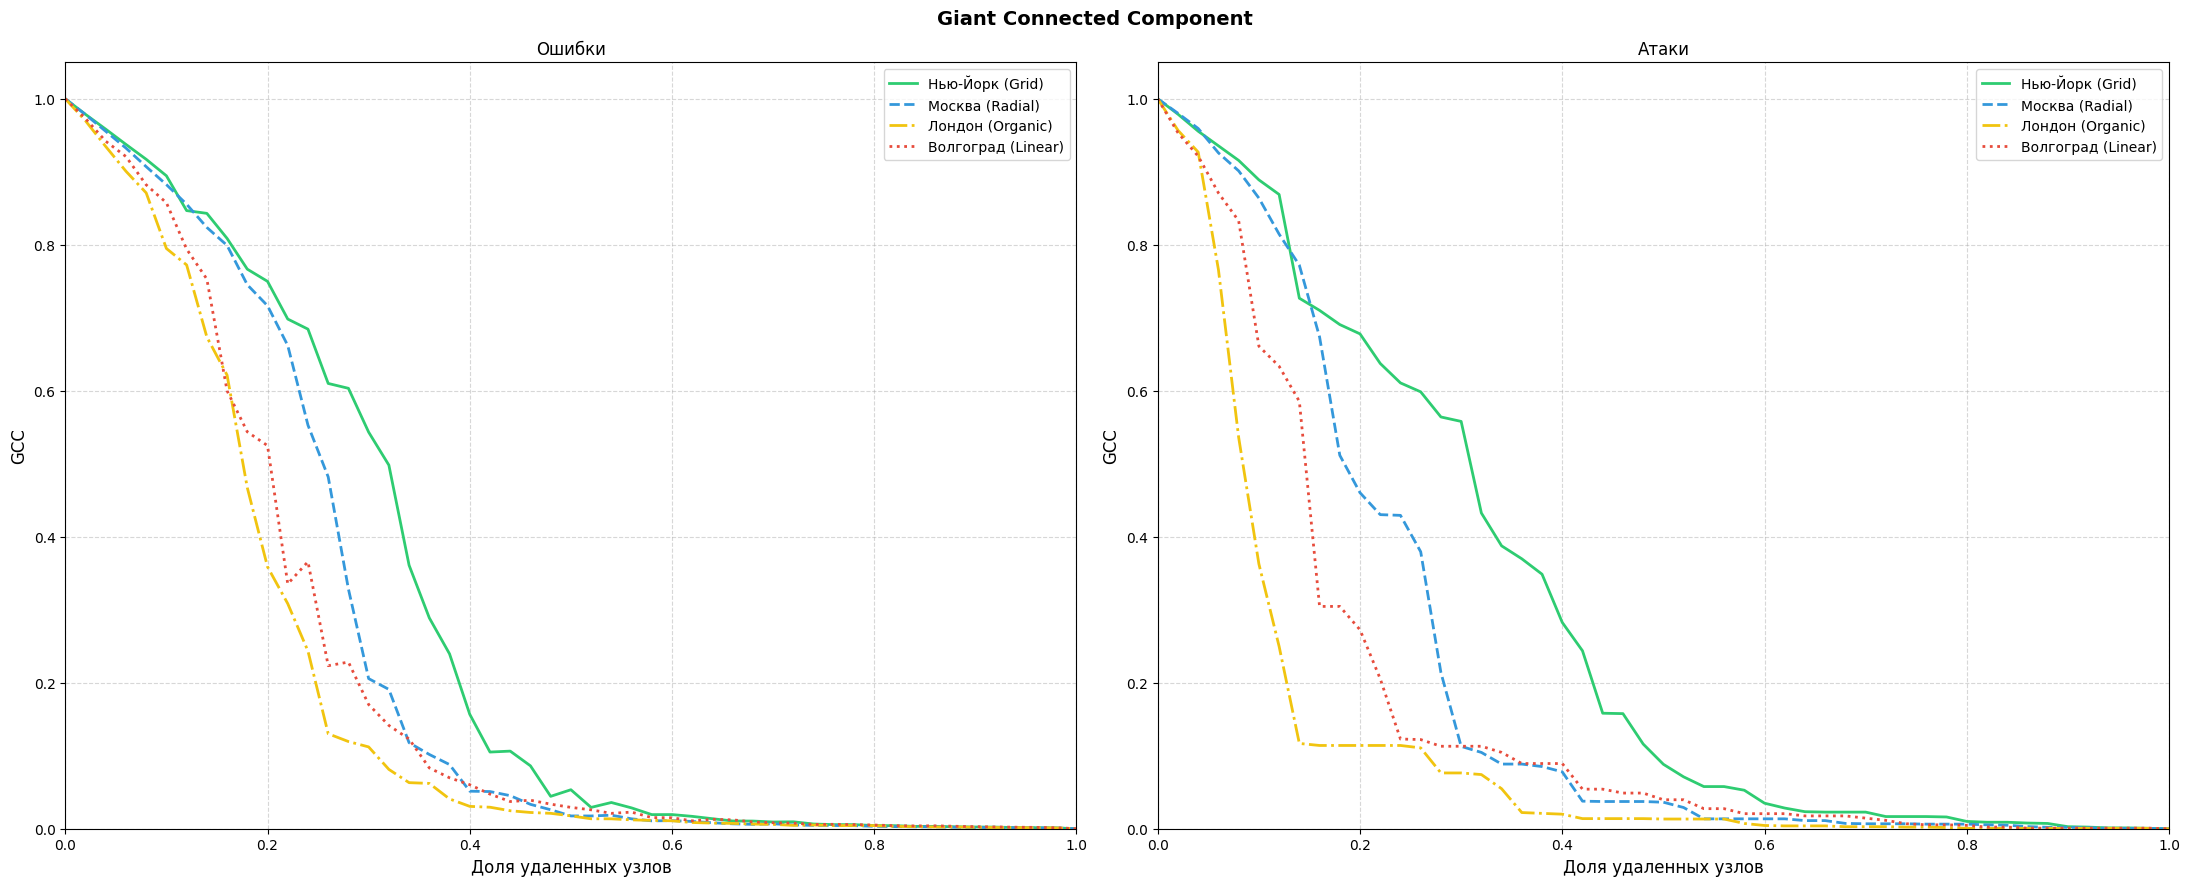

In [24]:
plot_comparison(error, attack, "gcc", "Giant Connected Component", "GCC")

### Average Size of Isolated Clusters

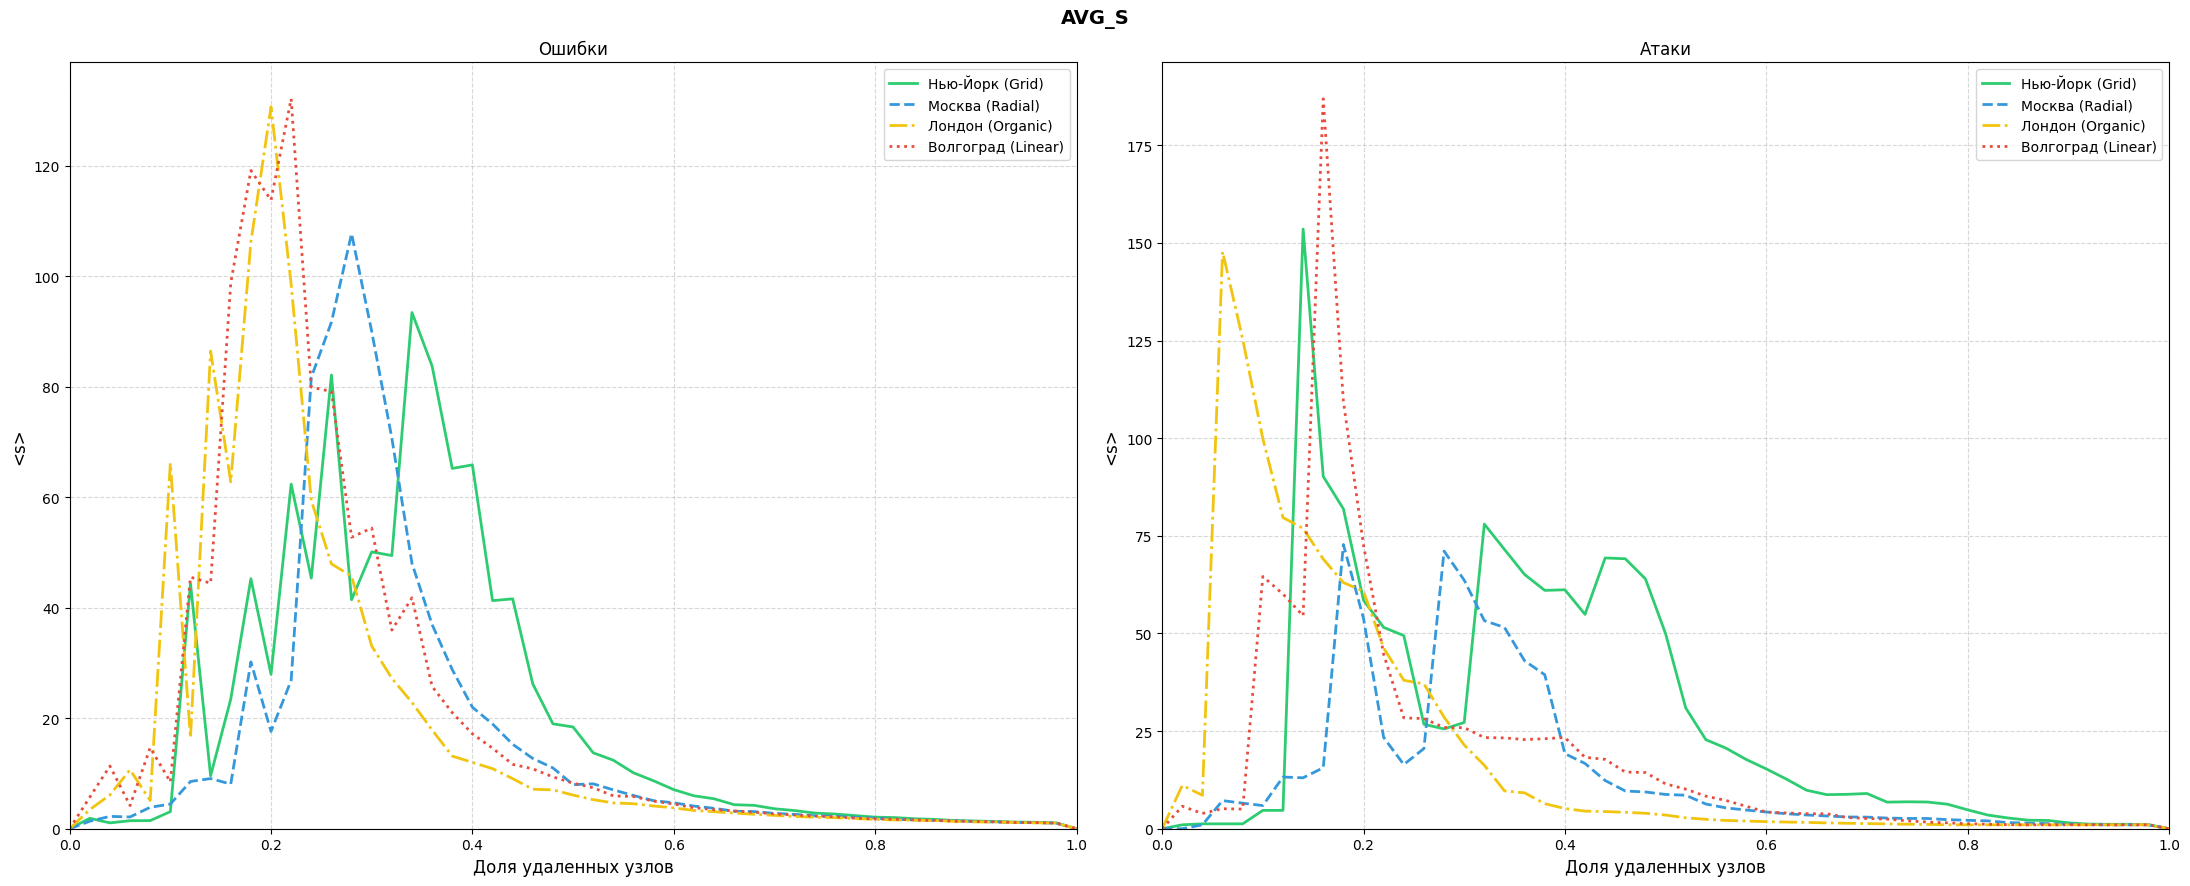

In [26]:
plot_comparison(error, attack, "avg_s", "AVG_S", "<s>")

### Topological Diameter

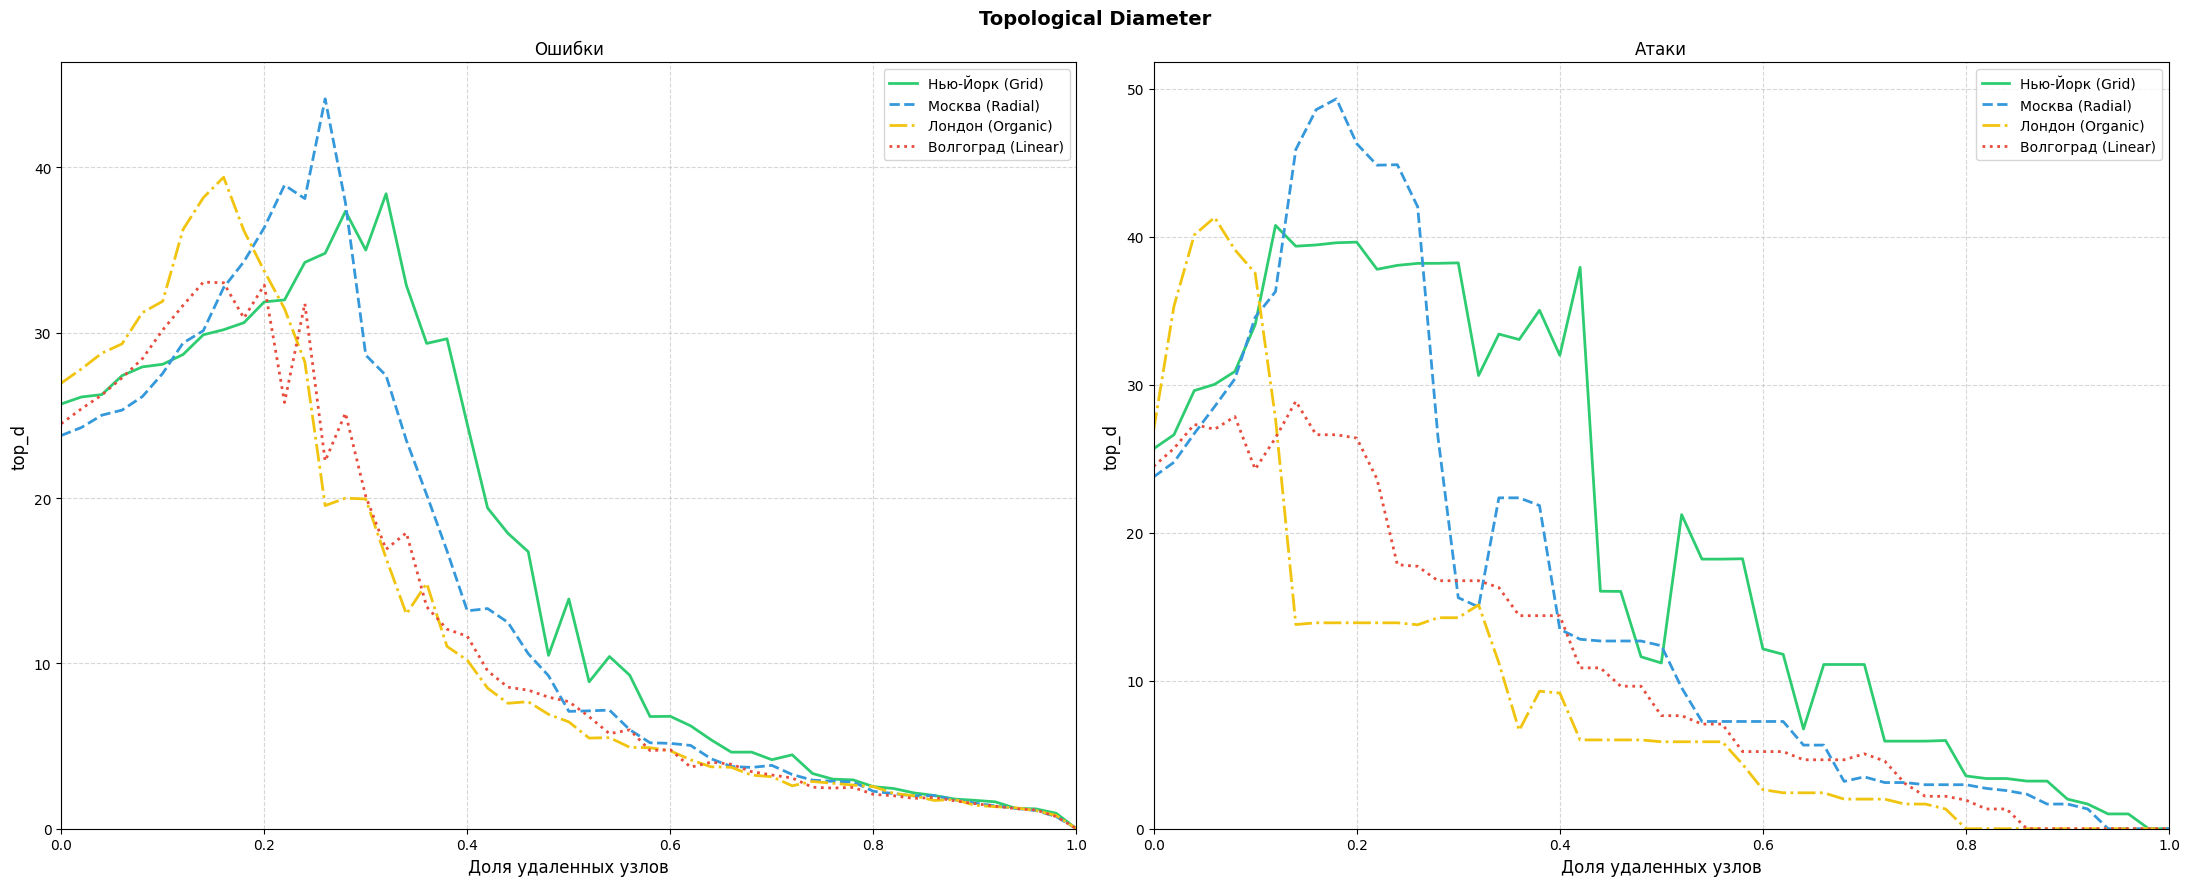

In [27]:
plot_comparison(error, attack, "top_d", "Topological Diameter", "top_d")

### Length Diameter

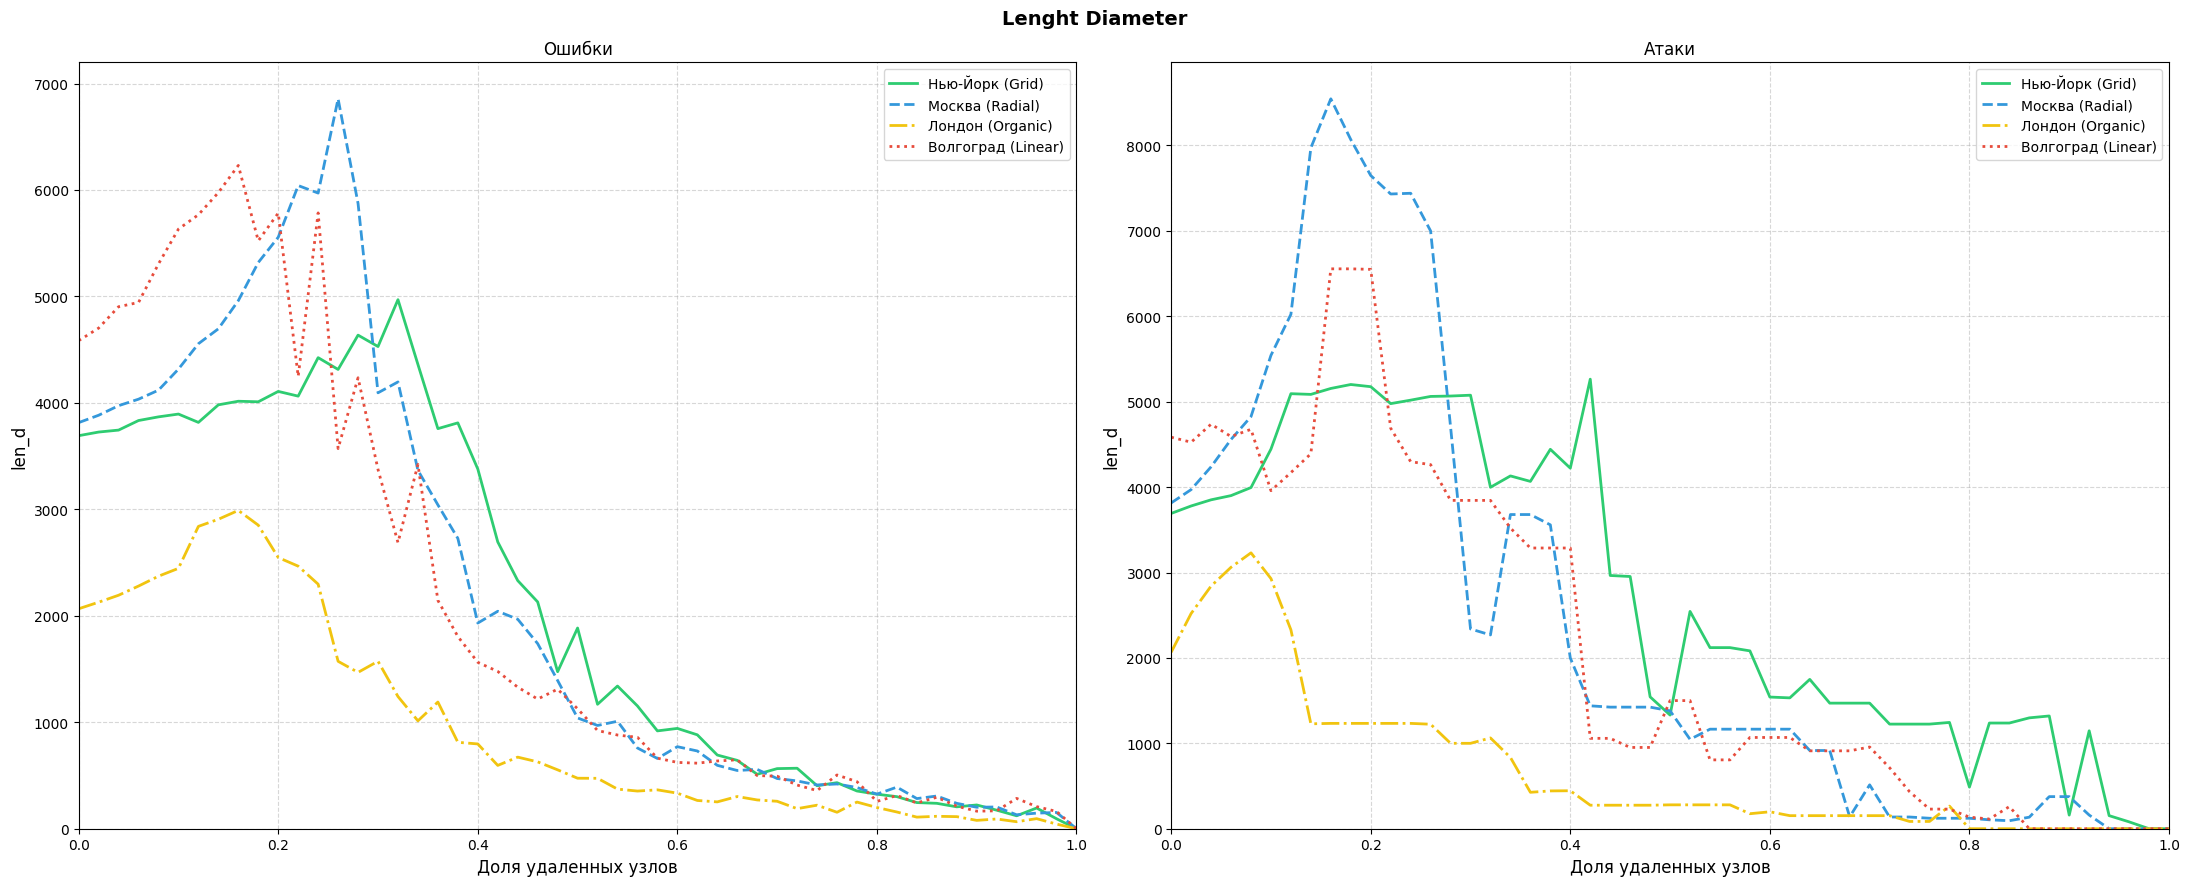

In [28]:
plot_comparison(error, attack, "len_d", "Lenght Diameter", "len_d")

### Global Efficiency

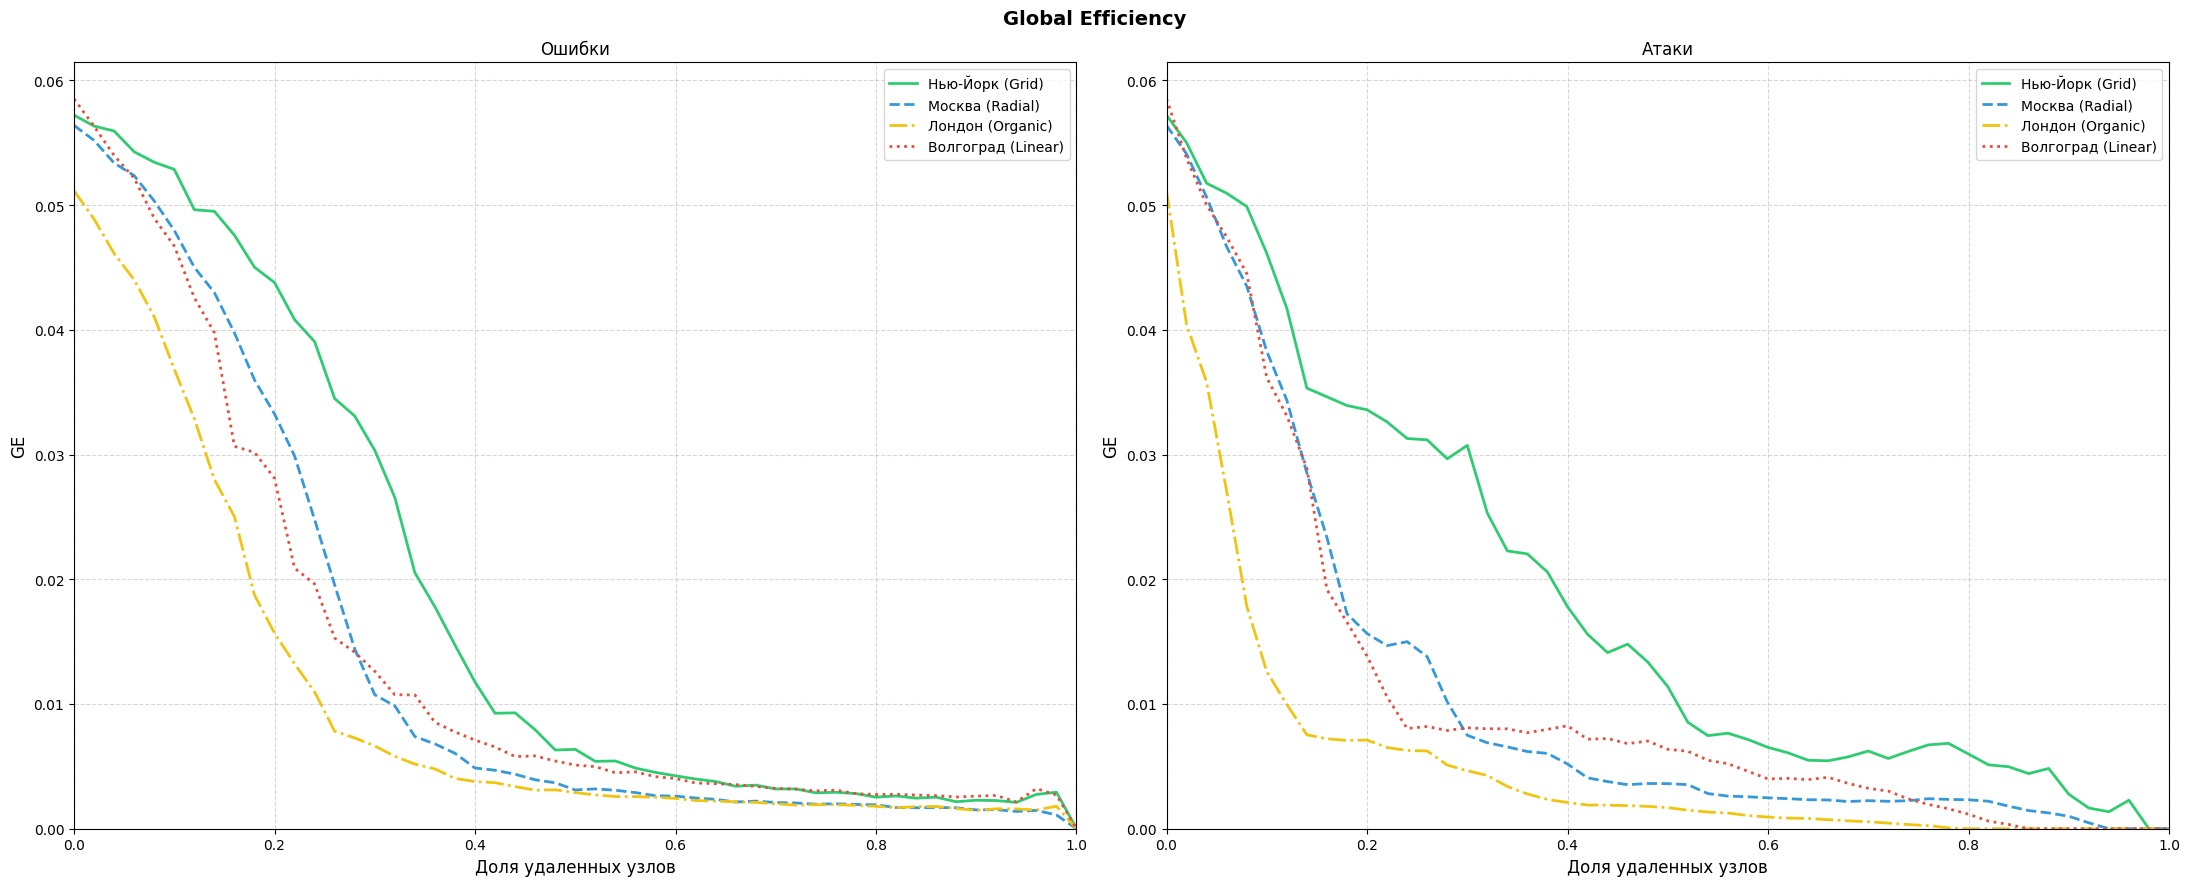

In [29]:
plot_comparison(error, attack, "ge", "Global Efficiency", "GE")

### Local Clustering Coefficient

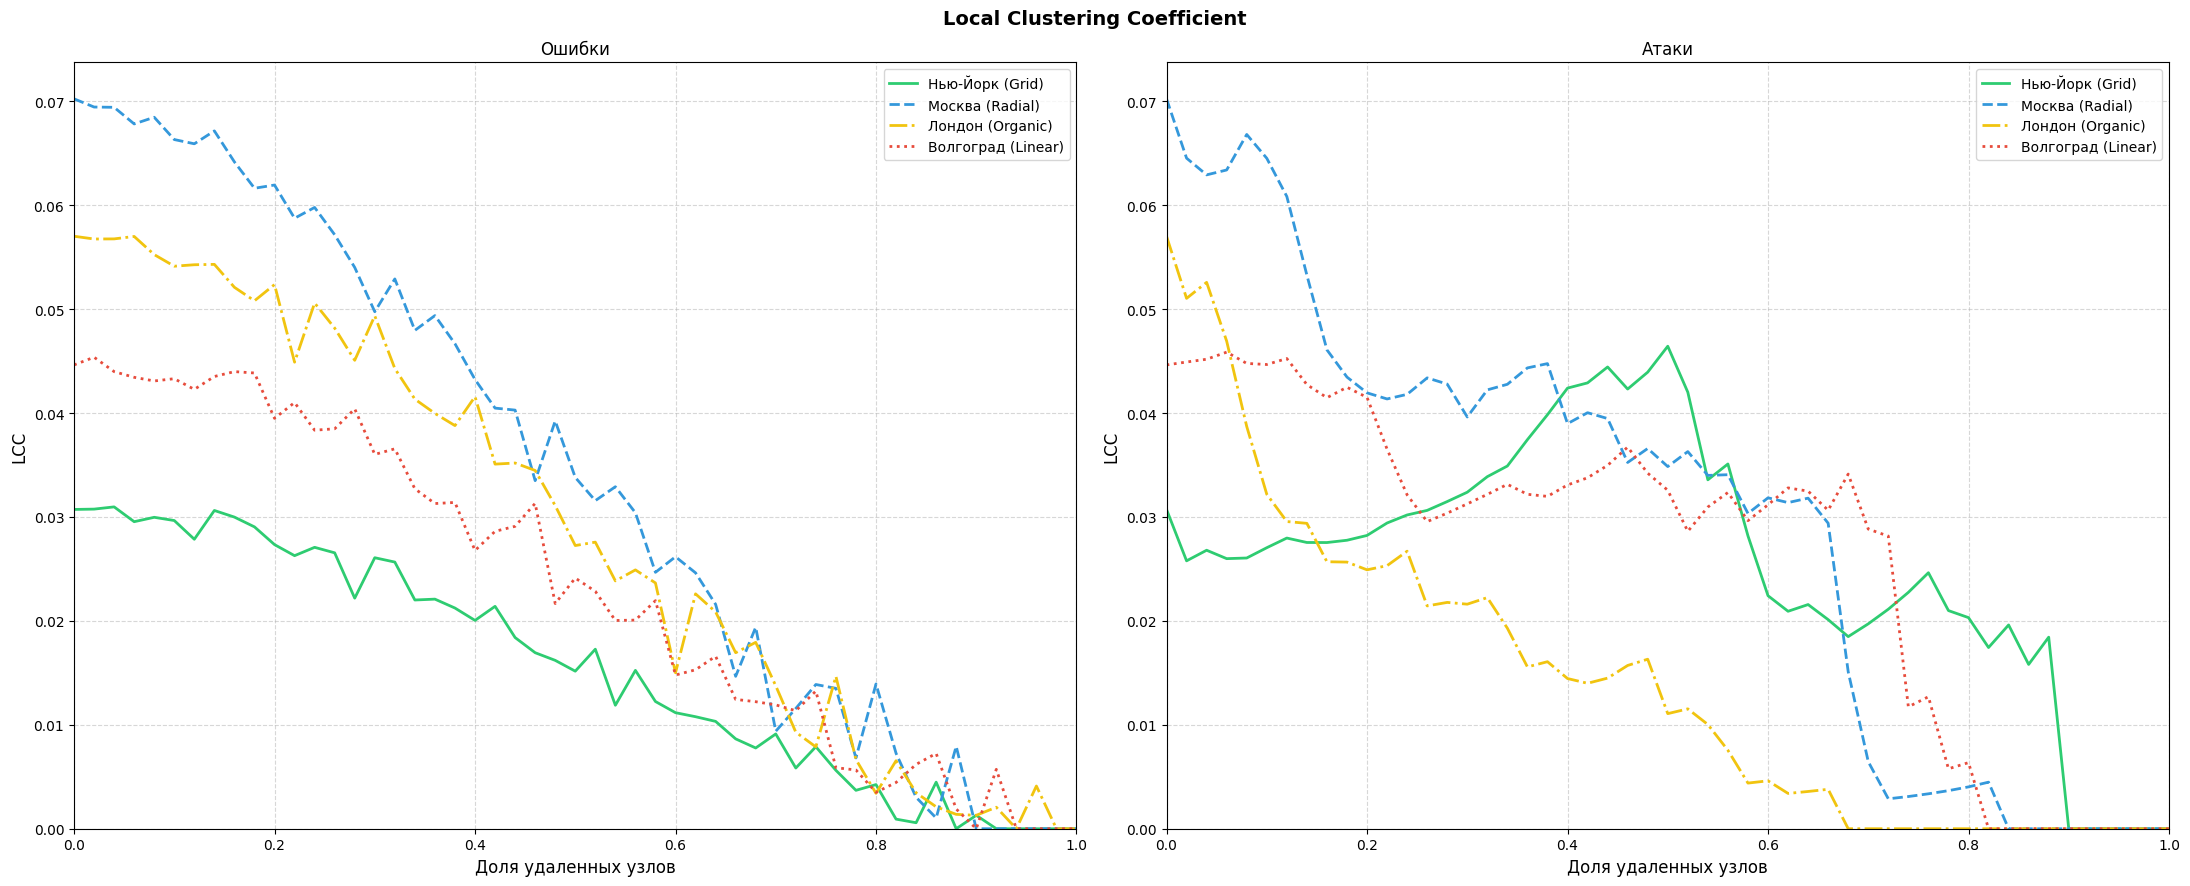

In [30]:
plot_comparison(error, attack, "lcc", "Local Clustering Coefficient", "LCC")